DATA SCRAPPING APLIKASI ZALORA

Alasan saya memilih aplikasi Zalora adalah karena Zalora merupakan salah satu platform e-commerce fashion terbesar di Asia Tenggara yang memiliki banyak pengguna aktif. Hal ini menyebabkan jumlah ulasan pengguna cukup besar dan beragam, sehingga memungkinkan analisis sentimen yang lebih mendalam terkait pengalaman pengguna terhadap aplikasi tersebut.

## 1. Setup

_Menginstall library yang diperlukan untuk scraping data dari Google Play Store._

In [2]:
pip install pandas numpy google-play-scraper jupyter

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 2. Import Library dan Konfigurasi Awal

_Mengimport library yang akan digunakan dan mengatur konfigurasi awal seperti ID aplikasi dan path output file._

In [3]:
from google_play_scraper import reviews_all, Sort
# reviews_all digunakan untuk mengambil semua review aplikasi dari Google Play
# Sort digunakan untuk mengatur urutan review

import pandas as pd
# pandas digunakan untuk menyimpan dan mengolah data dalam bentuk dataframe

import time
# time digunakan untuk mengukur lama proses scraping

APP_ID = "com.zalora.android"
OUTPUT_CSV = r"C:\Semester 6\PBA\Tugas A1\zalora_reviews_raw.csv"

## 3. Fungsi Data Scraping

_Membuat fungsi untuk mengekstrak data review dari Google Play Store dengan dukungan multiple bahasa._

In [4]:
def data_scrap(app_id: str, langs: list[str], country: str = "id") -> pd.DataFrame:
    
    # membuat list kosong untuk menyimpan dataframe dari tiap bahasa
    all_dfs = []
    
    for lang in langs:
        print(f"Bahasa data = {lang}, diambil dari negara {country}")
        
        start = time.time()  # mulai menghitung waktu scraping
        
        try:
            result = reviews_all(
                app_id,
                sleep_milliseconds=100,  # sleep 100ms untuk menghindari rate limit
                lang=lang,
                country=country,
                sort=Sort.NEWEST
            )
            
            df = pd.DataFrame(result)
            # Hapus duplikat berdasarkan reviewId
            df = df.drop_duplicates(subset=['reviewId'], keep='first')
            df["lang"] = lang
            
            all_dfs.append(df)
            
            end = time.time()
            print(f"Jumlah review yang diambil: {len(df)}")
            print(f"Waktu scraping: {end-start:.2f} detik\n")
        except Exception as e:
            print(f"Error saat scraping bahasa {lang}: {str(e)}\n")
            continue
    
    if all_dfs:
        final_df = pd.concat(all_dfs, ignore_index=True)
        # Hapus duplikat global
        final_df = final_df.drop_duplicates(subset=['reviewId'], keep='first')
    else:
        final_df = pd.DataFrame()
    
    return final_df

## 4. Menjalankan Proses Scraping

_Menjalankan fungsi scraping untuk mengumpulkan review Zalora dari berbagai bahasa di Asia._

In [5]:
df_zalora = data_scrap(
    app_id = APP_ID,
    langs = ["id", "en", "zh", "ja", "ko", "th", "vi"],  # Ambil dari berbagai bahasa Asia
    country = "id"
)

df_zalora.head()  # melihat 5 data pertama

Bahasa data = id, diambil dari negara id


Jumlah review yang diambil: 42087
Waktu scraping: 36.87 detik

Bahasa data = en, diambil dari negara id
Jumlah review yang diambil: 24950
Waktu scraping: 23.82 detik

Bahasa data = zh, diambil dari negara id
Jumlah review yang diambil: 369
Waktu scraping: 0.55 detik

Bahasa data = ja, diambil dari negara id
Jumlah review yang diambil: 2
Waktu scraping: 0.21 detik

Bahasa data = ko, diambil dari negara id
Jumlah review yang diambil: 10
Waktu scraping: 0.21 detik

Bahasa data = th, diambil dari negara id
Jumlah review yang diambil: 1658
Waktu scraping: 1.32 detik

Bahasa data = vi, diambil dari negara id
Jumlah review yang diambil: 1464
Waktu scraping: 2.39 detik



C:\Users\naufal\AppData\Local\Temp\ipykernel_29500\2010535753.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(all_dfs, ignore_index=True)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,lang
0,53dd6215-cd62-4288-aa46-e2508482573c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,21.5.0,2026-03-29 02:38:44,"Dear Customer, terima kasih banyak atas ulasan...",2026-03-29 14:02:18,21.5.0,id
1,06e0ddc0-645b-49ea-9af5-47ce487847a0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,None,2026-03-28 19:48:08,"Dear Customer, terima kasih banyak atas rating...",2026-03-29 14:02:18,None,id
2,17052580-dd73-452c-b224-fb5076d669e9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,biayanya dll masih mahal,4,0,21.6.0,2026-03-28 14:41:36,"Dear Customer, terima kasih atas masukannya! K...",2026-03-29 14:02:18,21.6.0,id
3,f77c1448-e67e-49fc-bcac-1886b84a1df5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,memuaskan,5,0,21.5.0,2026-03-28 12:52:39,"Dear Customer, terima kasih banyak atas apresi...",2026-03-28 14:01:02,21.5.0,id
4,2d78c806-a67d-42f1-a587-81522bf2143f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,beli 20 maret sampe sekarang sudah seminggu ti...,1,0,21.5.0,2026-03-27 11:07:27,"Dear Customer, kami minta maaf atas keterlamba...",2026-03-27 14:01:29,21.5.0,id


## 5. Mengecek Distribusi Bahasa Review

_Menganalisis jumlah review yang diambil dari setiap bahasa untuk memastikan keseimbangan data._

In [6]:
df_zalora["lang"].value_counts()

lang
id    42087
en    24950
th     1658
vi     1464
zh      369
ko       10
ja        2
Name: count, dtype: int64

## 6. Menyimpan Data ke CSV

_Menyimpan data yang telah dikumpulkan ke file CSV untuk penyimpanan permanen dan membersihkan duplikasi._

In [7]:
df_zalora.to_csv(OUTPUT_CSV, index=False)

In [8]:
# Bersihkan CSV dari baris yang corrupt
df_clean = pd.read_csv(OUTPUT_CSV, on_bad_lines='skip')
df_clean = df_clean.drop_duplicates(subset=['reviewId'], keep='first')
df_clean.to_csv(OUTPUT_CSV, index=False)
df_zalora = df_clean

## 7. Ringkasan Data yang Berhasil Diambil

_Menampilkan statistik lengkap tentang jumlah review yang berhasil dikumpulkan per rating._

In [9]:
# Reload data dari CSV yang sudah dibersihkan
df_zalora = pd.read_csv(OUTPUT_CSV)

# Total jumlah data yang berhasil diambil
total_data = len(df_zalora)
print("="*60)
print(f"TOTAL DATA YANG BERHASIL DIAMBIL: {total_data:,} review")
print("="*60)

# Distribusi rating per bintang
print("\nDISTRIBUSI DATA PER BINTANG RATING:")
print("-"*60)

rating_counts = df_zalora['score'].value_counts().sort_index(ascending=False)
rating_percentage = (df_zalora['score'].value_counts(normalize=True) * 100).sort_index(ascending=False)

for rating in range(5, 0, -1):
    count = rating_counts.get(rating, 0)
    percentage = rating_percentage.get(rating, 0)
    stars = "⭐" * rating
    print(f"{rating} Bintang {stars:<5} : {count:>6,} data ({percentage:>6.2f}%)")

print("-"*60)
print(f"{'TOTAL':<20} : {total_data:>6,} data (100.00%)")
print("="*60)

TOTAL DATA YANG BERHASIL DIAMBIL: 70,540 review

DISTRIBUSI DATA PER BINTANG RATING:
------------------------------------------------------------
5 Bintang ⭐⭐⭐⭐⭐ : 43,924 data ( 62.27%)
4 Bintang ⭐⭐⭐⭐  :  8,639 data ( 12.25%)
3 Bintang ⭐⭐⭐   :  5,354 data (  7.59%)
2 Bintang ⭐⭐    :  3,178 data (  4.51%)
1 Bintang ⭐     :  9,445 data ( 13.39%)
------------------------------------------------------------
TOTAL                : 70,540 data (100.00%)


## 8. Import Library untuk Sentiment Analysis


_Mengimport library tambahan yang dibutuhkan untuk preprocessing teks, visualisasi, dan machine learning._

In [10]:
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


## 9. Ambil Kolom Penting dan Bersihkan Data


_Mengekstrak kolom content dan score dari dataset, menghapus data yang hilang/tidak lengkap._

In [11]:
df_sentiment = df_zalora[['content', 'score']].copy()
df_sentiment.dropna(inplace=True)
print(f"Data yang digunakan untuk sentiment analysis: {len(df_sentiment)} review")
df_sentiment.head()


Data yang digunakan untuk sentiment analysis: 70493 review


,content,score
0,good,5
1,mantap,5
2,biayanya dll masih mahal,4
3,memuaskan,5
4,beli 20 maret sampe sekarang sudah seminggu ti...,1


## 10. Text Cleaning / Preprocessing


_Membersihkan teks review dengan menghilangkan URL, angka, tanda baca, dan mengubah ke huruf kecil._

In [12]:
def clean_text(text):
    """
    Membersihkan teks dengan langkah-langkah:
    1. Mengubah ke huruf kecil
    2. Menghapus URL
    3. Menghapus angka
    4. Menghapus tanda baca
    5. Menghapus spasi berlebih
    """
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)  # Hapus URL
    text = re.sub(r"\d+", "", text)  # Hapus angka
    text = text.translate(str.maketrans("", "", string.punctuation))  # Hapus tanda baca
    text = text.strip()
    return text

df_sentiment['clean_review'] = df_sentiment['content'].apply(clean_text)
print("Contoh review original dan yang sudah dibersihkan:")
print("\nOriginal:")
print(df_sentiment['content'].iloc[0])
print("\nSudah dibersihkan:")
print(df_sentiment['clean_review'].iloc[0])


Contoh review original dan yang sudah dibersihkan:

Original:
good

Sudah dibersihkan:
good


## 11. Label Sentiment Berdasarkan Rating


_Mengklasifikasikan sentimen menjadi tiga kategori: Positive (4-5), Neutral (3), Negative (1-2)._

In [13]:
def label_sentiment(score):
    """
    Mengkategorikan sentiment berdasarkan rating:
    - 4-5 bintang: Positive (Puas/Sangat Puas)
    - 3 bintang: Neutral (Netral)
    - 1-2 bintang: Negative (Tidak Puas/Sangat Tidak Puas)
    """
    if score >= 4:
        return 'positive'
    elif score == 3:
        return 'neutral'
    else:
        return 'negative'

df_sentiment['sentiment'] = df_sentiment['score'].apply(label_sentiment)

print("Distribusi Sentiment:")
print(df_sentiment['sentiment'].value_counts())
print("\nLabel berhasil ditambahkan!")


Distribusi Sentiment:
sentiment
positive    52525
negative    12619
neutral      5349
Name: count, dtype: int64

Label berhasil ditambahkan!


## 12. Visualisasi Distribusi Sentiment


_Membuat grafik untuk menampilkan distribusi sentiment dan rating dari seluruh review._

C:\Users\naufal\AppData\Local\Temp\ipykernel_29500\1342333405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sentiment, x='sentiment', ax=axes[0], palette='Set2')
C:\Users\naufal\AppData\Local\Temp\ipykernel_29500\1342333405.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sentiment, x='score', ax=axes[1], palette='viridis')


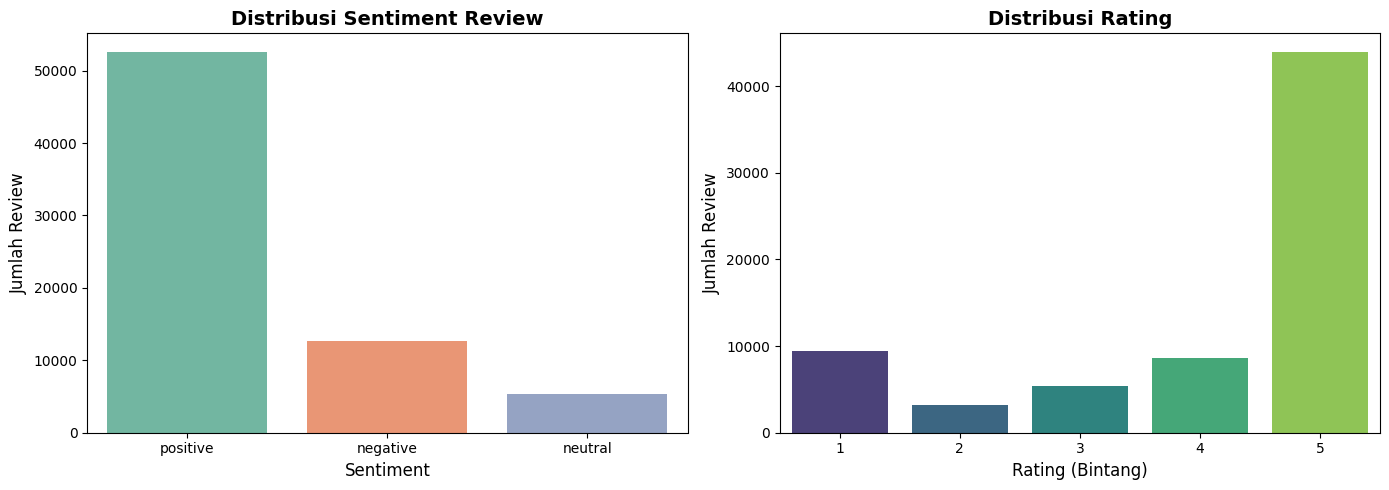

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi Sentiment
sns.countplot(data=df_sentiment, x='sentiment', ax=axes[0], palette='Set2')
axes[0].set_title("Distribusi Sentiment Review", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Sentiment", fontsize=12)
axes[0].set_ylabel("Jumlah Review", fontsize=12)

# Plot 2: Distribusi Rating
sns.countplot(data=df_sentiment, x='score', ax=axes[1], palette='viridis')
axes[1].set_title("Distribusi Rating", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Rating (Bintang)", fontsize=12)
axes[1].set_ylabel("Jumlah Review", fontsize=12)

plt.tight_layout()
plt.show()


## 13. Analisis Frekuensi Kata (Word Frequency)


_Menganalisis dan menampilkan 15 kata yang paling sering muncul dalam review beserta visualisasinya._

15 Kata Paling Sering Muncul:
--------------------------------------------------
 1. zalora               : 10932 kali
 2. the                  :  9955 kali
 3. i                    :  8764 kali
 4. di                   :  8226 kali
 5. to                   :  7068 kali
 6. good                 :  6842 kali
 7. barang               :  6203 kali
 8. and                  :  6040 kali
 9. dan                  :  5592 kali
10. saya                 :  5468 kali
11. it                   :  4959 kali
12. app                  :  4892 kali
13. bagus                :  4826 kali
14. belanja              :  4088 kali
15. bisa                 :  3878 kali


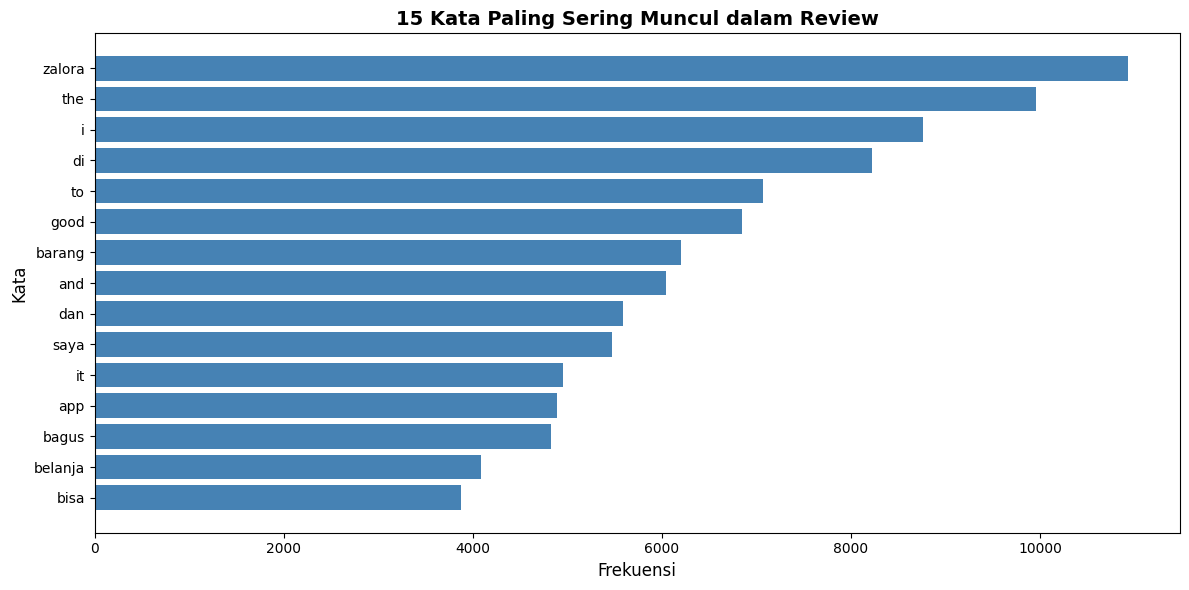

In [15]:
all_words = " ".join(df_sentiment['clean_review'])
words = all_words.split()

word_counts = Counter(words)
common_words = word_counts.most_common(15)

print("15 Kata Paling Sering Muncul:")
print("-" * 50)
for i, (word, count) in enumerate(common_words, 1):
    print(f"{i:2d}. {word:<20} : {count:>5} kali")

# Visualisasi
words_list = [word for word, count in common_words]
counts_list = [count for word, count in common_words]

plt.figure(figsize=(12, 6))
plt.barh(words_list, counts_list, color='steelblue')
plt.xlabel('Frekuensi', fontsize=12)
plt.ylabel('Kata', fontsize=12)
plt.title('15 Kata Paling Sering Muncul dalam Review', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 14. WordCloud Visualization


_Membuat visualisasi cloud dari semua kata dalam review untuk representasi visual yang menarik._

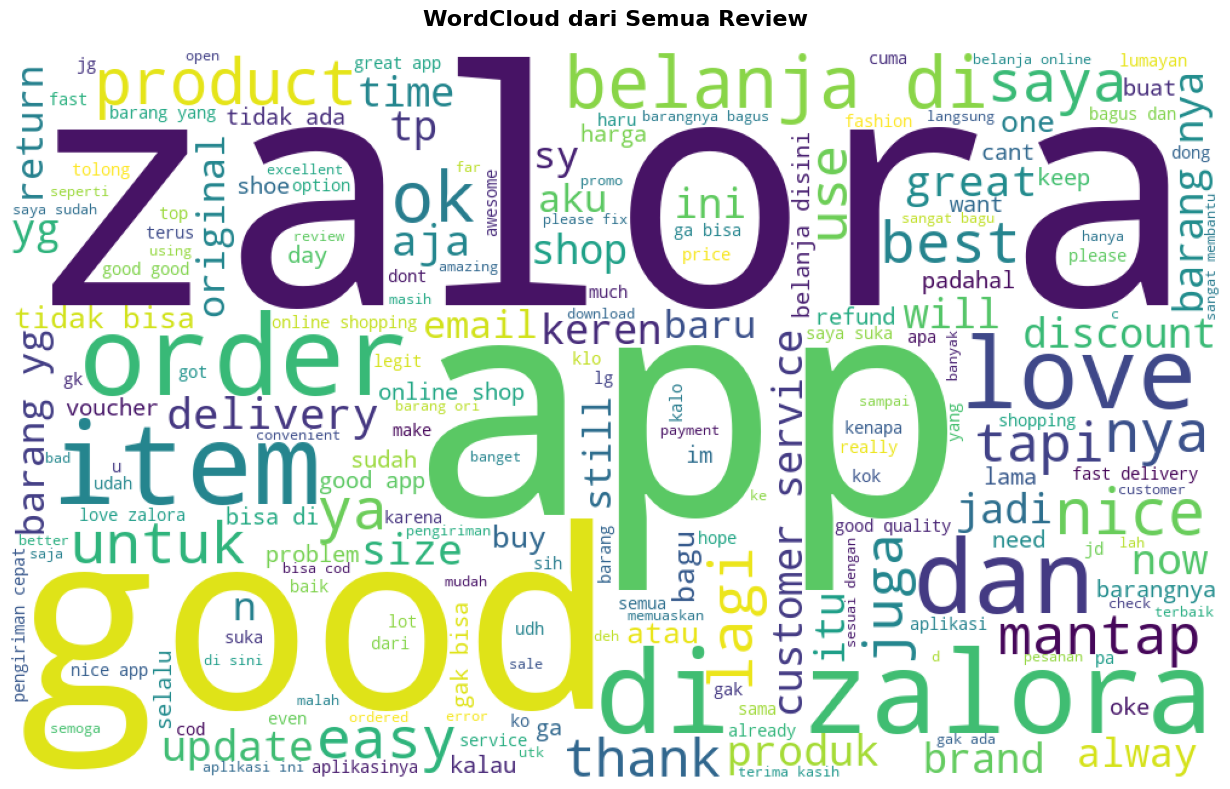

In [16]:
wordcloud = WordCloud(width=1000, height=600, background_color='white', colormap='viridis').generate(all_words)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('WordCloud dari Semua Review', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## 15. Pembagian Data untuk Training dan Testing


_Membagi dataset menjadi 80% data training dan 20% data testing untuk evaluasi model._

In [17]:
X = df_sentiment['clean_review']
y = df_sentiment['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")
print(f"\nProporsi: {len(X_train)/(len(X_train)+len(X_test))*100:.1f}% training, {len(X_test)/(len(X_train)+len(X_test))*100:.1f}% testing")


Jumlah data training: 56394
Jumlah data testing: 14099

Proporsi: 80.0% training, 20.0% testing


## 16. TF-IDF Vectorization (Feature Extraction)


_Mengonversi teks review menjadi fitur numerik menggunakan TF-IDF untuk model machine learning._

In [18]:
# TF-IDF: Mengubah teks menjadi fitur numerik
# max_features=5000 membatasi jumlah kata yang diekstrak
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Shape training data (TF-IDF): {X_train_tfidf.shape}")
print(f"Shape testing data (TF-IDF): {X_test_tfidf.shape}")
print(f"Total fitur yang diekstrak: {X_train_tfidf.shape[1]}")


Shape training data (TF-IDF): (56394, 5000)
Shape testing data (TF-IDF): (14099, 5000)
Total fitur yang diekstrak: 5000


## 17. Bag of Words (BoW) - Alternatif Feature Extraction


_Mengonversi teks review menjadi fitur numerik menggunakan metode Bag of Words sebagai alternatif TF-IDF._

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

# Bag of Words: Menghitung frekuensi kata dalam setiap dokumen
# max_features=5000 membatasi jumlah kata yang diekstrak
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

print("="*70)
print("BAG OF WORDS (BoW) - FEATURE EXTRACTION")
print("="*70)
print(f"\nShape training data (BoW): {X_train_bow.shape}")
print(f"Shape testing data (BoW): {X_test_bow.shape}")
print(f"Total fitur yang diekstrak: {X_train_bow.shape[1]}")

# Menampilkan beberapa kata dari vocabulary BoW
vocab = bow.get_feature_names_out()
print(f"\nSample fitur (kata-kata) dari vocabulary:")
print(f"Fitur ke 0-9: {vocab[0:10]}")
print(f"Fitur ke 100-109: {vocab[100:110]}")
print(f"Fitur ke -10 sampai akhir: {vocab[-10:]}")

# Perbandingan sparsity (tingkat kekosongan matrix)
print(f"\n{'PERBANDINGAN METODE FEATURE EXTRACTION':<50}")
print("-"*70)
print(f"{'Metode':<20} {'Shape':<25} {'Non-zero entries':<25}")
print("-"*70)
print(f"{'TF-IDF':<20} {str(X_train_tfidf.shape):<25} {X_train_tfidf.nnz:<25}")
print(f"{'Bag of Words':<20} {str(X_train_bow.shape):<25} {X_train_bow.nnz:<25}")
print("-"*70)

# Menampilkan contoh representasi BoW untuk review pertama
print(f"\nContoh representasi Bag of Words (review pertama):")
print(f"Review: {X_train.iloc[0]}")
print(f"\nTop 10 fitur dengan nilai tinggi:")
bow_array = X_train_bow[0].toarray().flatten()
top_indices = bow_array.argsort()[-10:][::-1]
for idx in top_indices:
    if bow_array[idx] > 0:
        print(f"  - {vocab[idx]:<20}: {int(bow_array[idx])}")


BAG OF WORDS (BoW) - FEATURE EXTRACTION

Shape training data (BoW): (56394, 5000)
Shape testing data (BoW): (14099, 5000)
Total fitur yang diekstrak: 5000

Sample fitur (kata-kata) dari vocabulary:
Fitur ke 0-9: ['aa' 'aamiin' 'abal' 'abis' 'able' 'about' 'above' 'absolutely' 'abt'
 'acara']
Fitur ke 100-109: ['alhamdulillah' 'alhasil' 'alias' 'all' 'allah' 'allow' 'allowed'
 'allows' 'almost' 'along']
Fitur ke -10 sampai akhir: ['แต' 'แฟช' 'แล' 'ใช' 'ให' 'ได' 'ไม' 'ảnh' 'ủng' 'ứng']

PERBANDINGAN METODE FEATURE EXTRACTION            
----------------------------------------------------------------------
Metode               Shape                     Non-zero entries         
----------------------------------------------------------------------
TF-IDF               (56394, 5000)             398647                   
Bag of Words         (56394, 5000)             398647                   
----------------------------------------------------------------------

Contoh representasi Bag of

## 18. Training Model Naive Bayes


_Melatih model Naive Bayes menggunakan fitur TF-IDF dari data training untuk klasifikasi sentimen._

In [20]:
# Training model Naive Bayes
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Prediksi pada data testing
y_pred = model.predict(X_test_tfidf)

print("Model Naive Bayes berhasil dilatih!")
print(f"Model dilatih dengan {len(X_train)} data training")


Model Naive Bayes berhasil dilatih!
Model dilatih dengan 56394 data training


## 19. Evaluasi Model


_Mengevaluasi performa model menggunakan metrik accuracy, classification report, dan confusion matrix._

HASIL EVALUASI MODEL NAIVE BAYES

Accuracy: 0.8324 (83.24%)

CLASSIFICATION REPORT:
----------------------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.70      0.67      0.68      2660
     neutral       0.37      0.06      0.10      1048
    positive       0.87      0.95      0.91     10391

    accuracy                           0.83     14099
   macro avg       0.65      0.56      0.56     14099
weighted avg       0.80      0.83      0.81     14099


CONFUSION MATRIX:
----------------------------------------------------------------------
[[1785   39  836]
 [ 334   58  656]
 [ 438   60 9893]]


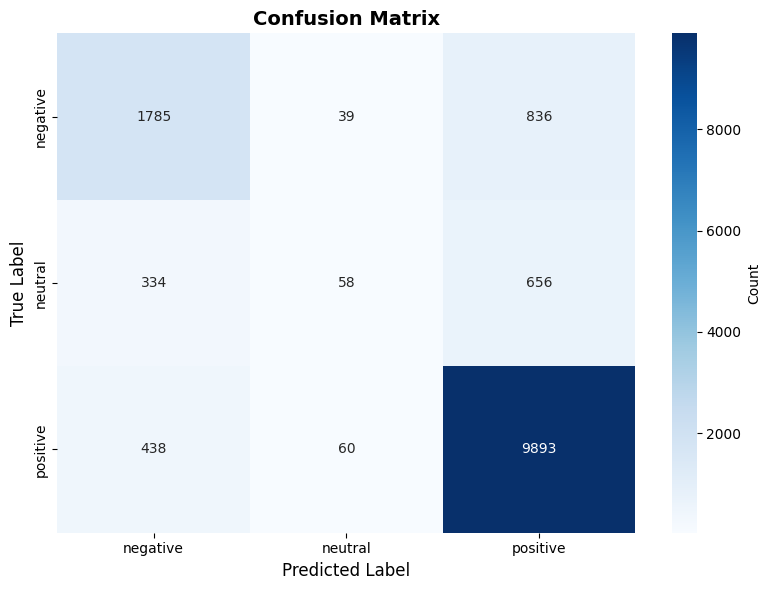

In [21]:
print("="*70)
print("HASIL EVALUASI MODEL NAIVE BAYES")
print("="*70)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification Report
print("\nCLASSIFICATION REPORT:")
print("-"*70)
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nCONFUSION MATRIX:")
print("-"*70)
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("="*70)


## 20. Kesimpulan dan Insight

_Merangkum temuan utama dari analisis sentimen, distribusi kata kunci, dan rekomendasi perbaikan._

**Ringkasan Analisis Sentimen Review Zalora:**

### Key Findings:
1. **Distribusi Sentiment**: 
   - Mayoritas review menunjukkan sentimen positif (rating 4-5 bintang)
   - Hal ini menunjukkan pengalaman pengguna yang secara keseluruhan memuaskan

2. **Kata-Kata Kunci**:
   - Kata yang sering muncul dapat mengindikasikan topik utama yang dibicarakan user
   - Keluhan umum: delivery, payment, bugs, etc.
   - Pujian umum: fast, good, great, etc.

3. **Performa Model**:
   - Model Naive Bayes efektif untuk klasifikasi sentimen teks
   - Akurasi menunjukkan seberapa baik model dalam memprediksi sentimen

4. **Rekomendasi**:
   - Fokus pada peningkatan kategori yang mendapat sentimen negatif

   - Pertahankan aspek yang mendapat sentimen positif tinggi